# Supplementary Figures S4–S5: grouped non-spatial analyses

Draw S4–S5 from the included per-cell arrays and analysis tables. The cells calculate the plotted summaries and save new PDF and PNG files.

## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/nonspatial.md).


## Load figure inputs

In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import calculate_nonspatial_panels, load_nonspatial_figures, write_nonspatial_tables

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "nonspatial_figures"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_nonspatial_figures()
{"weinreb_cells": len(results.weinreb.cells.times), "scnt_cells": len(results.scnt.cells.times)}

{'weinreb_cells': 49302, 'scnt_cells': 20547}

## Recalculate panel values

In [2]:
panels = calculate_nonspatial_panels(results)
tables = write_nonspatial_tables(panels, output_dir)
sorted(path.name for path in tables.values())

['scnt_direction.csv',
 'scnt_distribution.csv',
 'scnt_pathways.csv',
 'summary.csv',
 'weinreb_clone_fate.csv',
 'weinreb_concordance.csv',
 'weinreb_distribution.csv',
 'weinreb_pathways.csv']

## Draw and save the figure

In [3]:
from reproduction.paper_figures import draw_supplementary
figures = draw_supplementary([4, 5], output_dir, results_dir=results.source_dir,
                             data=results, panels=panels)
{figure_id: [path.name for path in paths] for figure_id, paths in figures.items()}

{'s4': ['S4.pdf', 'S4.png'], 's5': ['S5.pdf', 'S5.png']}

## Preview the generated figures

These PNG files were written by `draw_supplementary` in the preceding
cell; they are not input files.

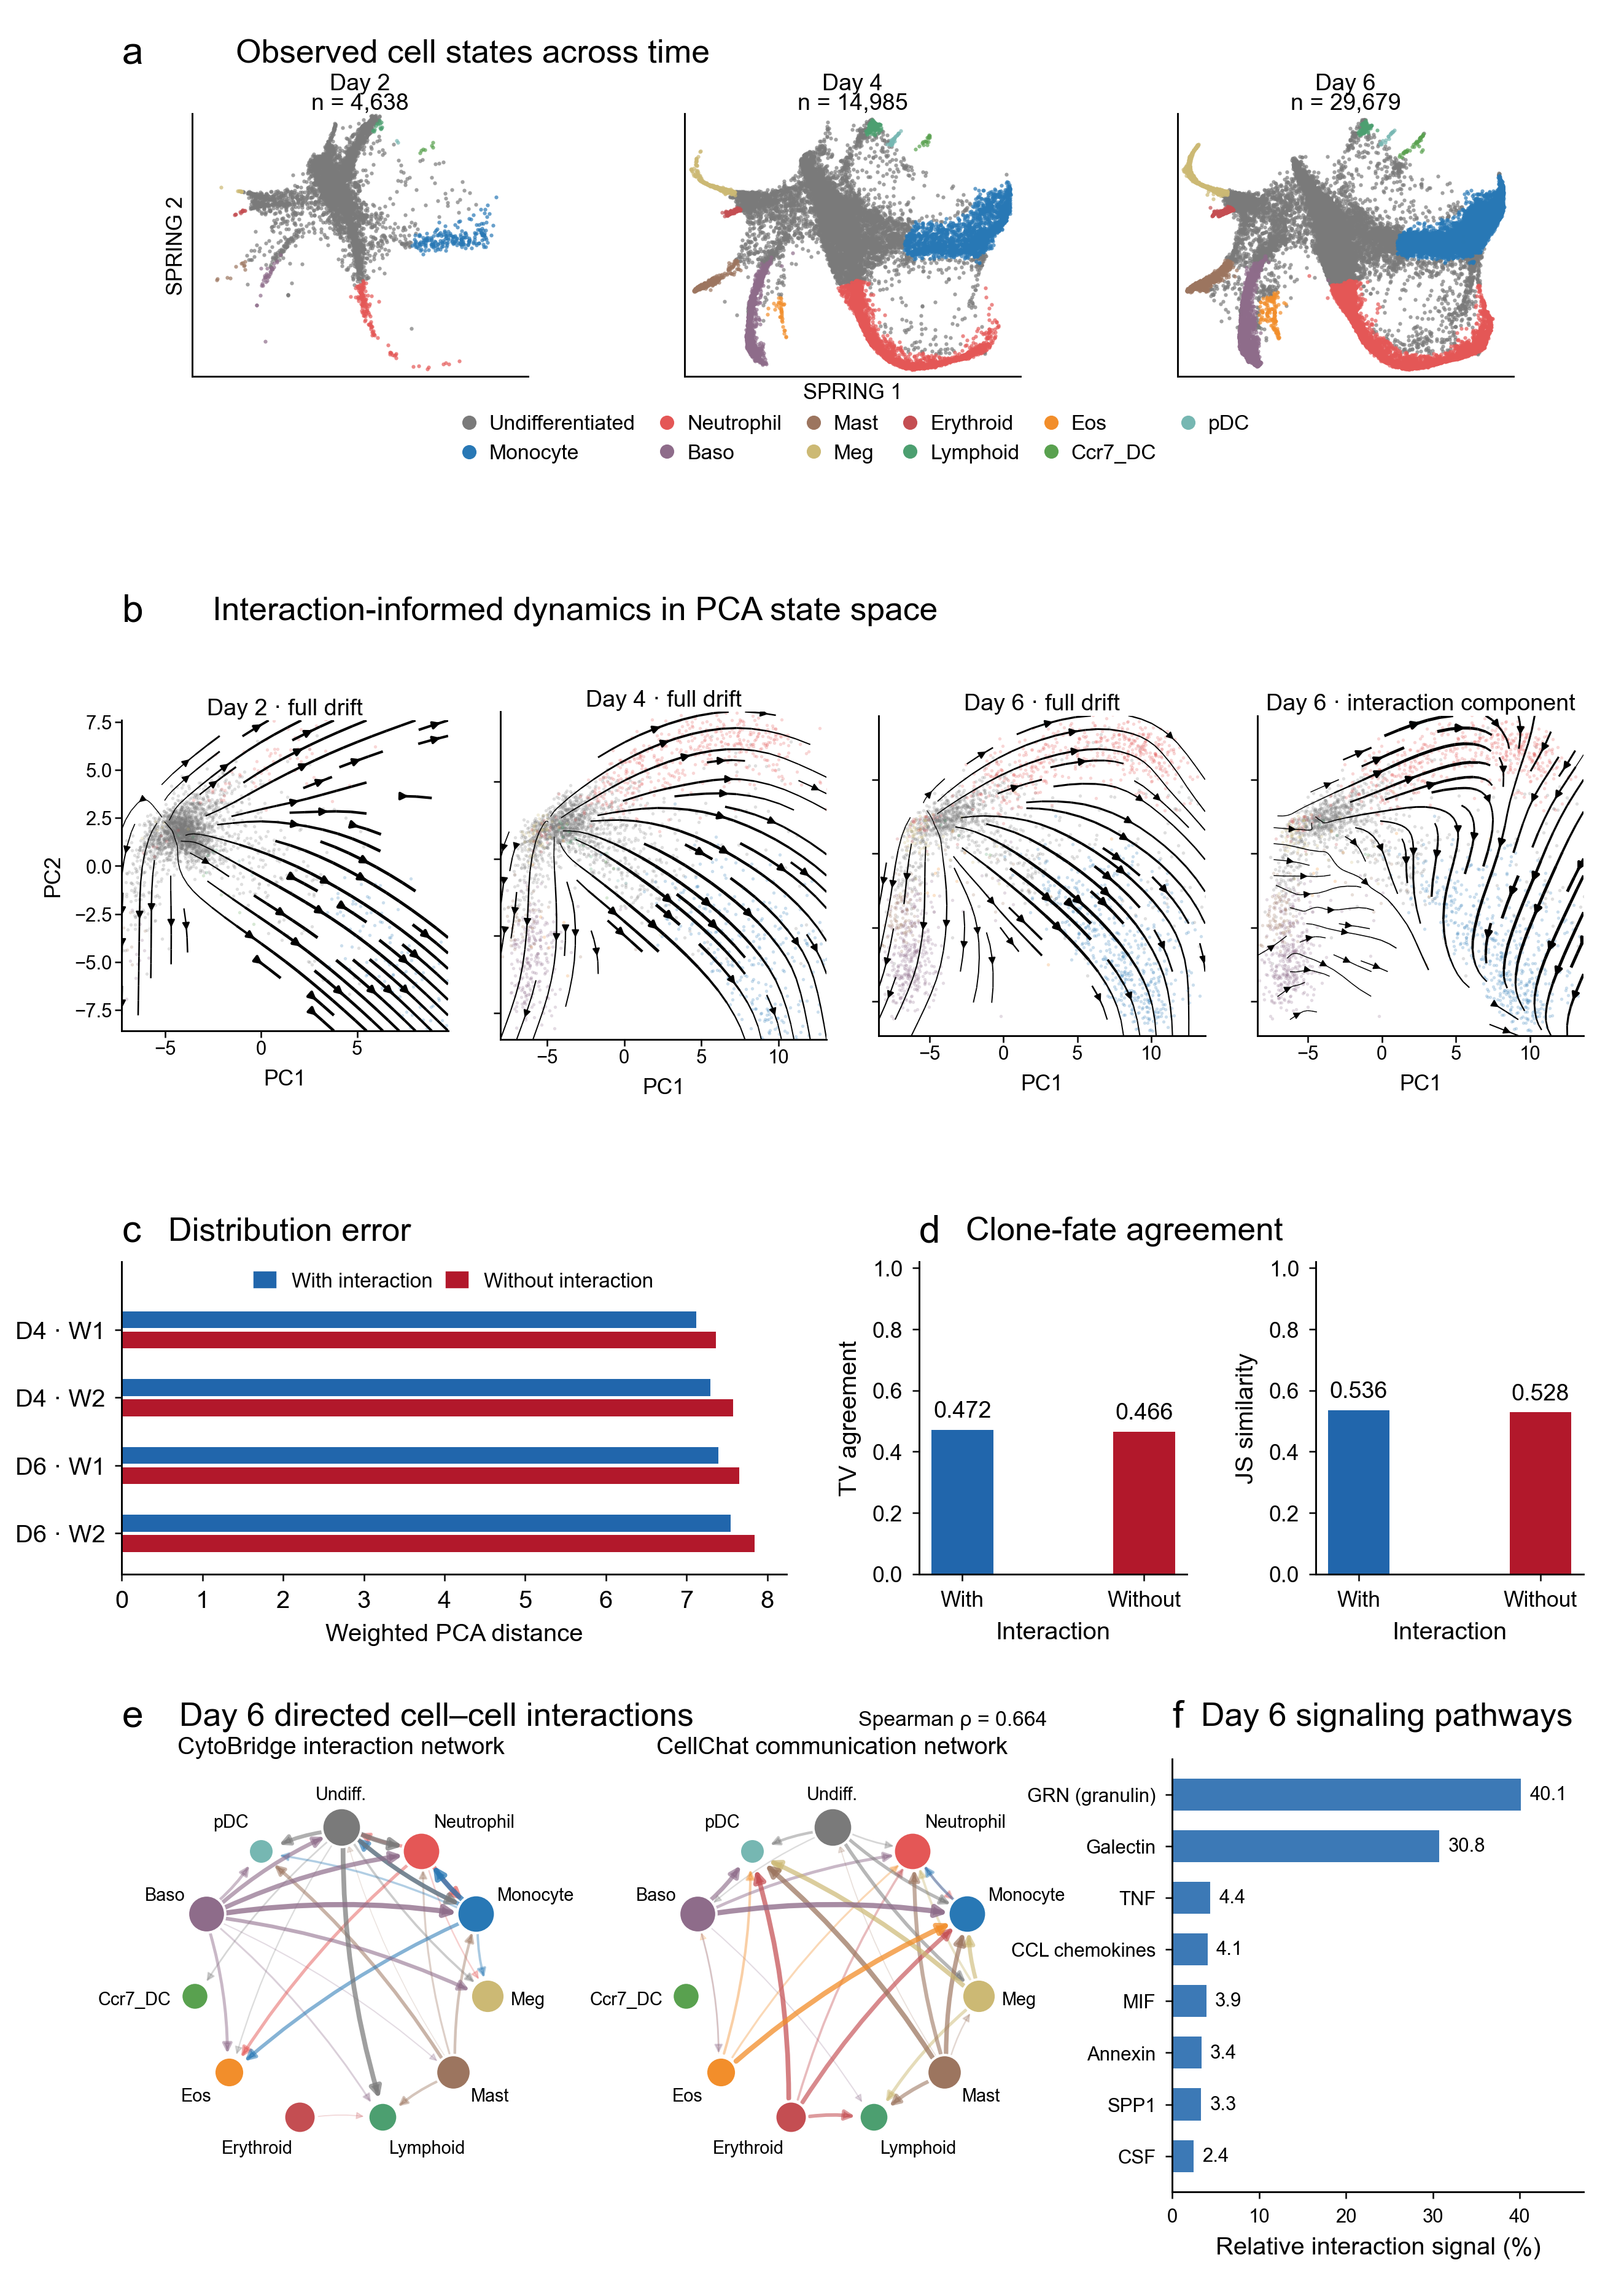

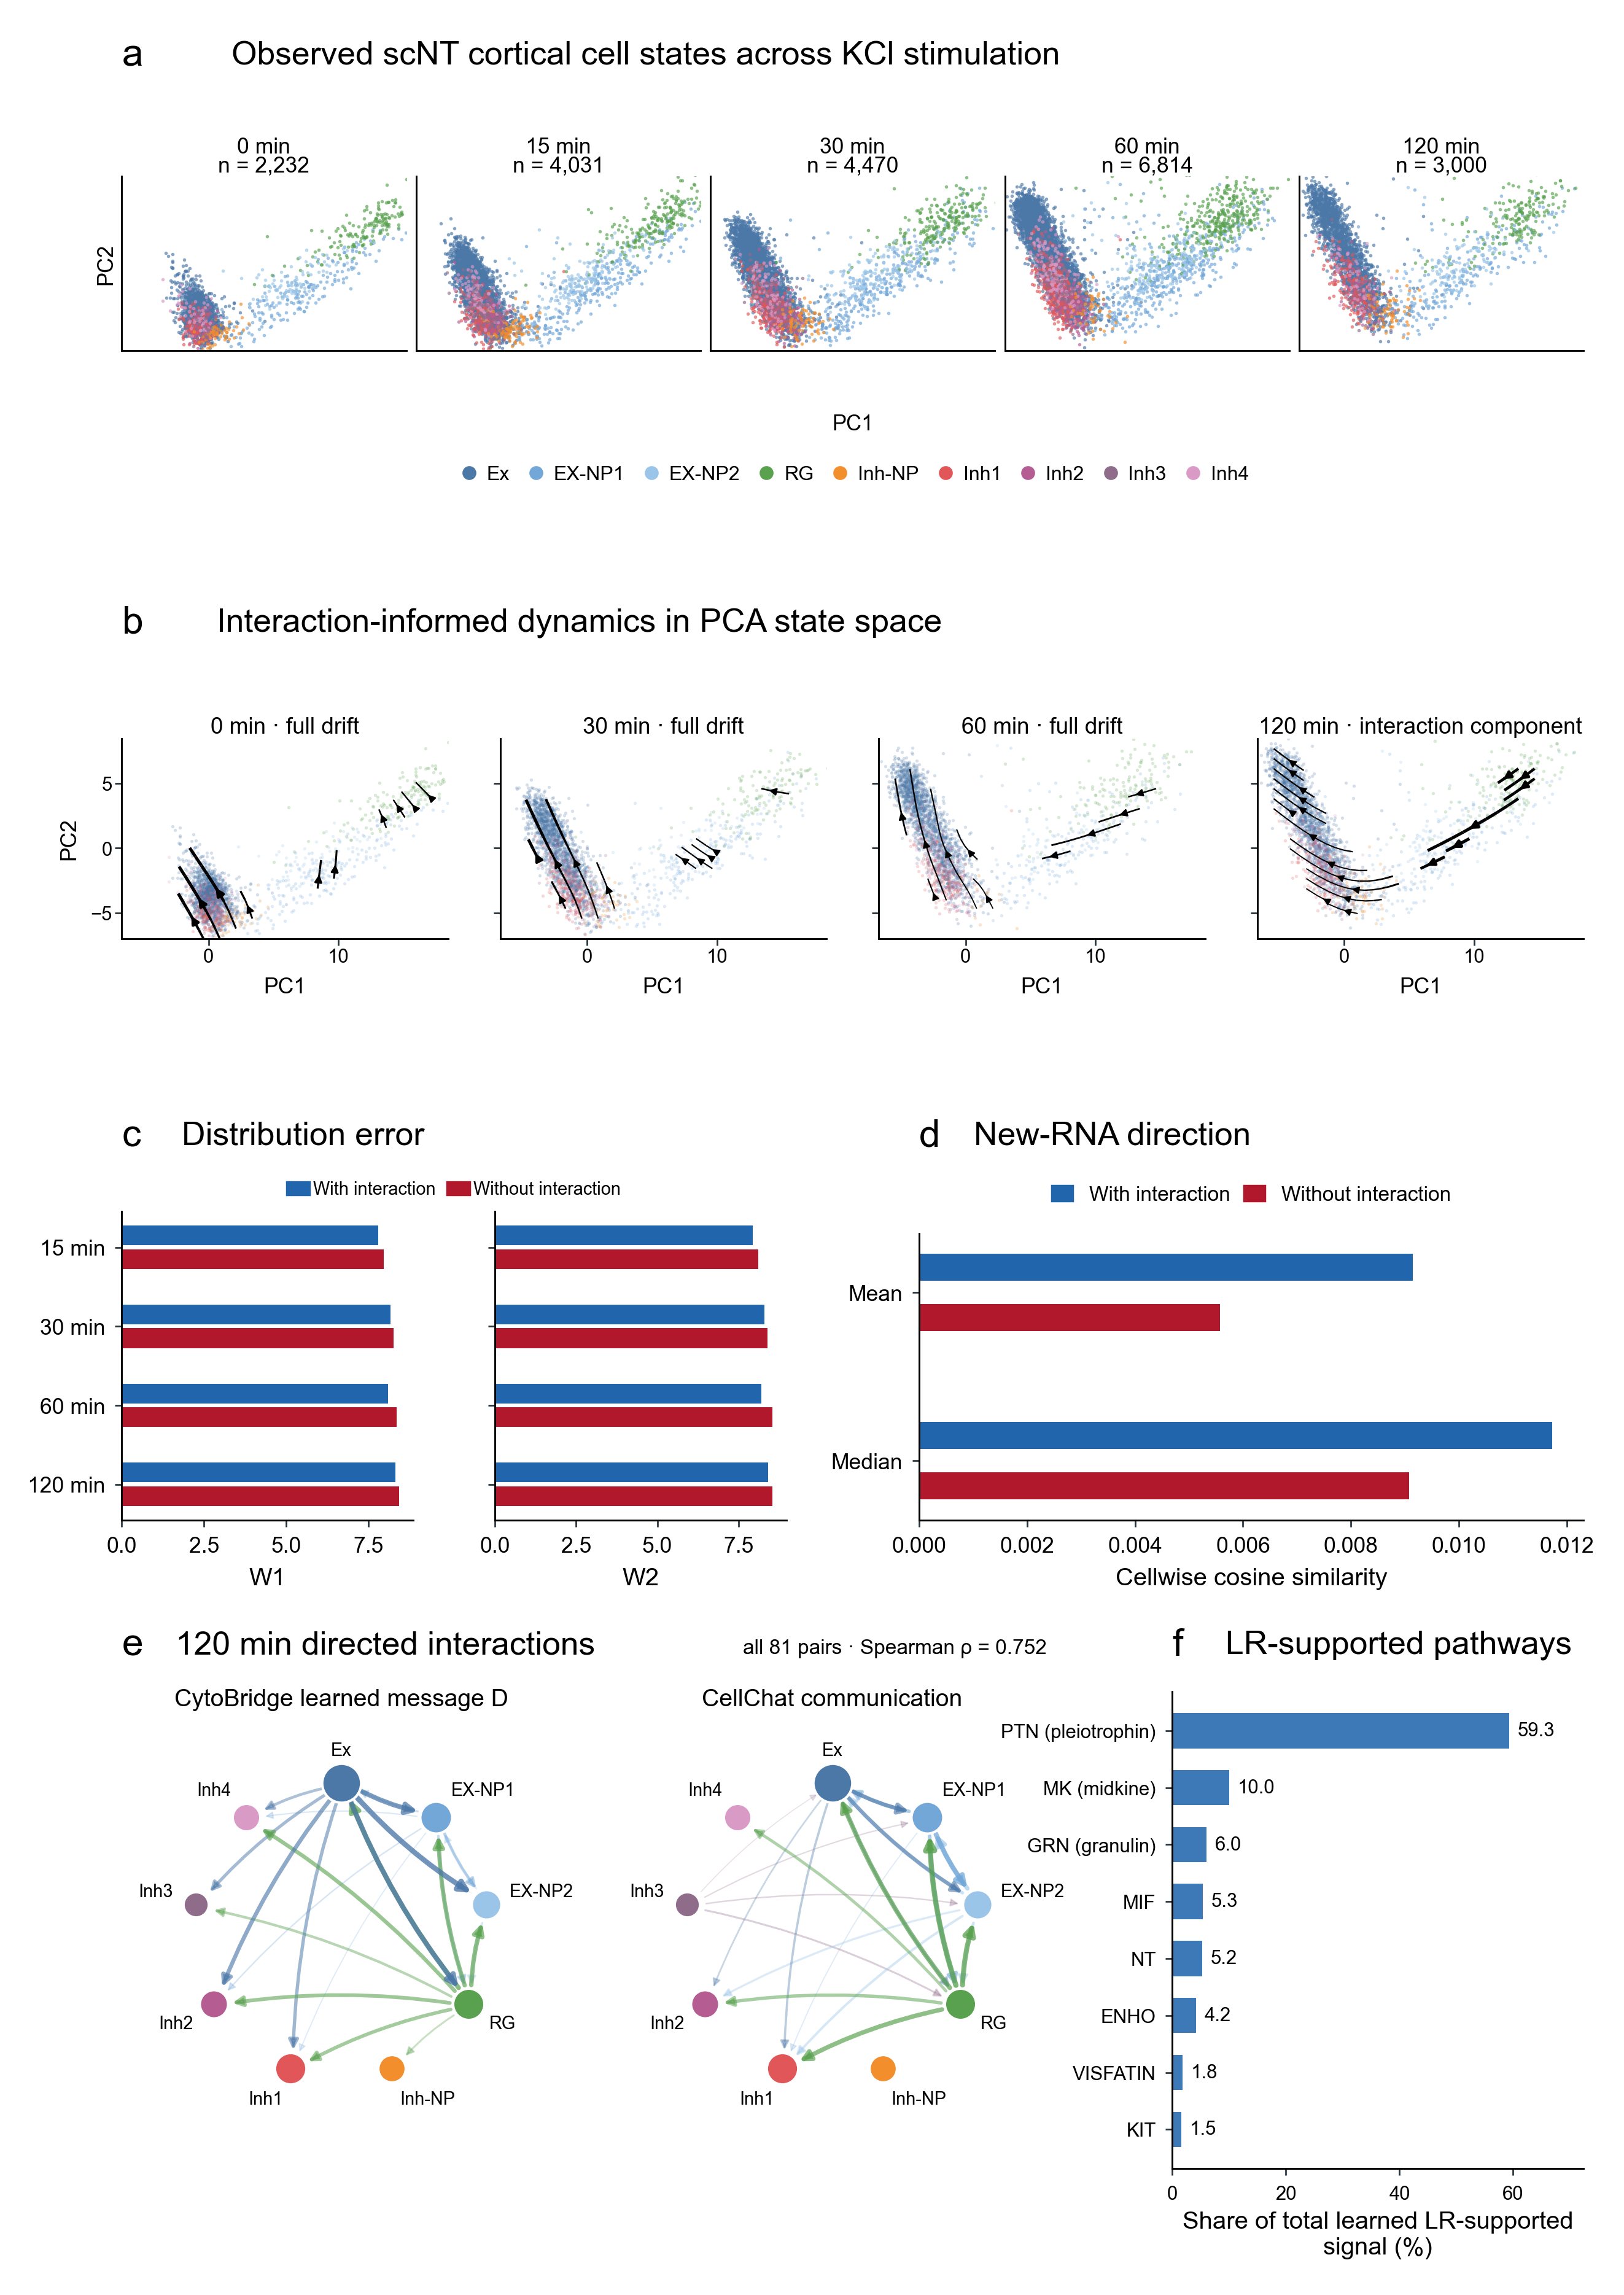

In [4]:
for figure_id, (_, png_path) in figures.items():
    print(figure_id.upper())
    display(Image(filename=str(png_path), width=720))